### Data Preprocessing

In [178]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from nltk.tokenize import RegexpTokenizer
import gensim
from gensim.models import KeyedVectors, Word2Vec

In [179]:
df = pd.read_csv('movies_metadata.csv')
df.head()

C:\Users\Priyam Kumar\AppData\Local\Temp\ipykernel_14372\3991525872.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('movies_metadata.csv')


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [180]:
df.shape

(45466, 24)

In [181]:
df.isnull().sum()

adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64

In [182]:
df = df.dropna(subset=["overview", "genres", "title"])
df = df[df["overview"].str.strip() != ""]
df = df.reset_index(drop=True)

In [183]:
df.isnull().sum()

adult                        0
belongs_to_collection    40070
budget                       0
genres                       0
homepage                 36740
id                           0
imdb_id                     15
original_language           10
original_title               0
overview                     0
popularity                   0
poster_path                343
production_companies         0
production_countries         0
release_date                71
revenue                      0
runtime                      0
spoken_languages             0
status                      64
tagline                  24097
title                        0
video                        0
vote_average                 0
vote_count                   0
dtype: int64

In [184]:
cols = [
    'genres',
    'title',
    'overview',
    'vote_average',
    'vote_count'
]

df = df[cols]
df = df.reset_index(drop=True)
df.head()

,genres,title,overview,vote_average,vote_count
0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",Toy Story,"Led by Woody, Andy's toys live happily in his ...",7.7,5415.0
1,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",Jumanji,When siblings Judy and Peter discover an encha...,6.9,2413.0
2,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",Grumpier Old Men,A family wedding reignites the ancient feud be...,6.5,92.0
3,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",6.1,34.0
4,"[{'id': 35, 'name': 'Comedy'}]",Father of the Bride Part II,Just when George Banks has recovered from his ...,5.7,173.0


In [185]:
df['genres'].unique().tolist()

["[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",
 "[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",
 "[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'Comedy'}]",
 "[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]",
 "[{'id': 35, 'name': 'Comedy'}]",
 "[{'id': 28, 'name': 'Action'}, {'id': 80, 'name': 'Crime'}, {'id': 18, 'name': 'Drama'}, {'id': 53, 'name': 'Thriller'}]",
 "[{'id': 35, 'name': 'Comedy'}, {'id': 10749, 'name': 'Romance'}]",
 "[{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}, {'id': 18, 'name': 'Drama'}, {'id': 10751, 'name': 'Family'}]",
 "[{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}, {'id': 53, 'name': 'Thriller'}]",
 "[{'id': 12, 'name': 'Adventure'}, {'id': 28, 'name': 'Action'}, {'id': 53, 'name': 'Thriller'}]",
 "[{'id': 35, 'name': 'Comedy'}, {'id': 27, 'name': 'Horror'}]",
 "[{'i

In [186]:
import ast

def parse_genres(x):
    try:
        return [i['name'] for i in ast.literal_eval(x)]
    except:
        return []

df['genres'] = df['genres'].apply(parse_genres)

In [187]:
df = df[df["genres"].apply(len) > 0]
df = df.reset_index(drop=True)

In [188]:
genre_list = df['genres'].tolist()
# split by '|'
words = set()
for g in genre_list:
    for genre in g:
        words.add(genre)
words

{'Action',
 'Adventure',
 'Animation',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'Foreign',
 'History',
 'Horror',
 'Music',
 'Mystery',
 'Romance',
 'Science Fiction',
 'TV Movie',
 'Thriller',
 'War',
 'Western'}

In [189]:
# hello = df['genres'][4].split('|')
# hello
arr = np.zeros(42318, dtype=int)
for cat in words:
    df[cat] = arr

for i in range(42318):
    splits = df['genres'][i]
    for split in splits:
        df.loc[i, split] = 1
df.head()

,genres,title,overview,vote_average,vote_count,Western,Fantasy,TV Movie,History,Romance,...,Thriller,Horror,Family,Animation,Science Fiction,Music,Mystery,Crime,Foreign,Adventure
0,"[Animation, Comedy, Family]",Toy Story,"Led by Woody, Andy's toys live happily in his ...",7.7,5415.0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
1,"[Adventure, Fantasy, Family]",Jumanji,When siblings Judy and Peter discover an encha...,6.9,2413.0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1
2,"[Romance, Comedy]",Grumpier Old Men,A family wedding reignites the ancient feud be...,6.5,92.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,"[Comedy, Drama, Romance]",Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",6.1,34.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,[Comedy],Father of the Bride Part II,Just when George Banks has recovered from his ...,5.7,173.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### NLP for movie overviews

In [190]:
from nltk.tokenize import RegexpTokenizer
import re

tokenizer = RegexpTokenizer(r'\w+')

def tokenize_title(title):
    if isinstance(title, bytes):
        title = title.decode('utf-8', errors='ignore')
    else:
        title = str(title)

    title = re.sub(r'\(\d{4}\)', '', title)
    return tokenizer.tokenize(title.lower())

movie_words = df['overview'].apply(tokenize_title).tolist()


In [191]:
movie_words

[['led',
  'by',
  'woody',
  'andy',
  's',
  'toys',
  'live',
  'happily',
  'in',
  'his',
  'room',
  'until',
  'andy',
  's',
  'birthday',
  'brings',
  'buzz',
  'lightyear',
  'onto',
  'the',
  'scene',
  'afraid',
  'of',
  'losing',
  'his',
  'place',
  'in',
  'andy',
  's',
  'heart',
  'woody',
  'plots',
  'against',
  'buzz',
  'but',
  'when',
  'circumstances',
  'separate',
  'buzz',
  'and',
  'woody',
  'from',
  'their',
  'owner',
  'the',
  'duo',
  'eventually',
  'learns',
  'to',
  'put',
  'aside',
  'their',
  'differences'],
 ['when',
  'siblings',
  'judy',
  'and',
  'peter',
  'discover',
  'an',
  'enchanted',
  'board',
  'game',
  'that',
  'opens',
  'the',
  'door',
  'to',
  'a',
  'magical',
  'world',
  'they',
  'unwittingly',
  'invite',
  'alan',
  'an',
  'adult',
  'who',
  's',
  'been',
  'trapped',
  'inside',
  'the',
  'game',
  'for',
  '26',
  'years',
  'into',
  'their',
  'living',
  'room',
  'alan',
  's',
  'only',
  'hope',

### Train the movie words on 300 features using Word2Vec

In [192]:
# model = Word2Vec(
#     sentences=movie_words,
#     vector_size=300,
#     window=5,
#     min_count=1,
#     workers=4,
#     epochs=300
# )

In [193]:
# model.save("movie_words.model")

In [194]:
model = Word2Vec.load("movie_words.model")

In [195]:
model.wv.most_similar("love")

[('romance', 0.3796679377555847),
 ('relationship', 0.36002930998802185),
 ('bergmanesque', 0.34150344133377075),
 ('passion', 0.33335113525390625),
 ('hippolyte', 0.33177947998046875),
 ('mubarek', 0.3285759389400482),
 ('loves', 0.3256573975086212),
 ('picaresque', 0.3182731866836548),
 ('kellie', 0.3160938620567322),
 ('dinkah', 0.3157294690608978)]

In [196]:
model.wv.index_to_key

['the',
 'a',
 'and',
 'to',
 'of',
 'in',
 'is',
 'his',
 's',
 'with',
 'he',
 'her',
 'for',
 'on',
 'an',
 'by',
 'that',
 'who',
 'as',
 'their',
 'from',
 'but',
 'when',
 'they',
 'she',
 'has',
 'are',
 'at',
 'it',
 'him',
 'life',
 'one',
 'this',
 'into',
 'up',
 'young',
 'after',
 'out',
 'be',
 'new',
 'man',
 'film',
 'two',
 'love',
 'about',
 'all',
 'world',
 'family',
 'story',
 'have',
 'them',
 'will',
 'was',
 'old',
 'not',
 'time',
 'find',
 'woman',
 'only',
 'father',
 'which',
 'years',
 'can',
 'while',
 'where',
 't',
 'get',
 'wife',
 'finds',
 'year',
 'war',
 'back',
 'first',
 'what',
 'girl',
 'town',
 'other',
 'must',
 'lives',
 'more',
 'friends',
 'through',
 'home',
 'own',
 'been',
 'day',
 'school',
 'mother',
 'over',
 'way',
 'so',
 'people',
 'between',
 'help',
 'during',
 'three',
 'or',
 'son',
 'takes',
 'there',
 'becomes',
 'himself',
 'daughter',
 'now',
 'friend',
 'off',
 'take',
 'no',
 'most',
 'death',
 'before',
 'being',
 'city'

In [197]:
len(model.wv)

73575

In [198]:
model.corpus_count

42318

In [199]:
model.wv.similar_by_word('story')

[('tale', 0.6554180979728699),
 ('stories', 0.48913297057151794),
 ('drama', 0.4741153120994568),
 ('film', 0.44579455256462097),
 ('sverák', 0.4289959669113159),
 ('tiresias', 0.4244082570075989),
 ('thriller', 0.41995835304260254),
 ('biopic', 0.4110214114189148),
 ('vidas', 0.3938407003879547),
 ('documentary', 0.3929066061973572)]

### Average Word2Vec

In [200]:
import numpy as np
from gensim.models import Word2Vec

model = Word2Vec.load("movie_words.model")

avg = []

for words in movie_words:
    vectors = [model.wv[w] for w in words if w in model.wv]

    if len(vectors) == 0:
        movie_vec = np.zeros(300)
    else:
        movie_vec = np.mean(vectors, axis=0)

    avg.append(movie_vec)

avg_np = np.array(avg)

In [201]:
avg_np

array([[ 0.52937502,  0.11336465, -0.82390988, ...,  1.19224107,
        -0.66034466,  0.72077274],
       [ 0.26014611, -0.02027793, -0.87168777, ...,  0.84638482,
        -0.39524713,  1.0391053 ],
       [ 0.01800064, -0.27399611, -0.69944143, ...,  0.78408974,
        -0.20481493,  0.67319918],
       ...,
       [-0.93694019, -0.09203175, -0.58395624, ...,  1.39156175,
         0.29127061,  1.71943271],
       [-0.25685611, -0.61398977, -0.43554169, ...,  1.48189402,
         0.59179699,  1.20797205],
       [-0.22660342, -0.04167385, -0.01371561, ...,  0.55876648,
        -0.46038878,  0.64424294]], shape=(42318, 300))

In [202]:
avg_np.shape

(42318, 300)

In [203]:
df.drop(columns='genres', inplace=True)
df.head()

,title,overview,vote_average,vote_count,Western,Fantasy,TV Movie,History,Romance,Drama,...,Thriller,Horror,Family,Animation,Science Fiction,Music,Mystery,Crime,Foreign,Adventure
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",7.7,5415.0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
1,Jumanji,When siblings Judy and Peter discover an encha...,6.9,2413.0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,6.5,92.0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",6.1,34.0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,5.7,173.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [204]:
type(avg_np)

numpy.ndarray

In [205]:
from sklearn.preprocessing import normalize

In [206]:
genre_matrix = df.loc[:, 'Western':'Adventure'].to_numpy()
avg_np = normalize(avg_np)
genre_matrix_norm = normalize(genre_matrix)
type(genre_matrix)
movie_features = np.concatenate(
    [avg_np * 0.7, genre_matrix * 0.3],
    axis=1
)
movie_features.shape

(42318, 320)

### Movie Rating calculation for better recommendation

In [207]:
import numpy as np

C = df["vote_average"].mean()          
m = df["vote_count"].quantile(0.60)    
v = df["vote_count"]
R = df["vote_average"]

df["weighted_rating"] = (v/(v+m) * R) + (m/(m+v) * C)

In [208]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df["weighted_rating_norm"] = scaler.fit_transform(
    df[["weighted_rating"]]
)

In [209]:
movie_features.shape

(42318, 320)

In [210]:
nan_mask = np.isnan(movie_features)
nan_rows = np.unique(np.where(nan_mask)[0])
len(nan_rows)

df.loc[nan_rows, 'title'].head(20)

Series([], Name: title, dtype: object)

In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity
# cosine_sim = cosine_similarity(movie_features)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_movies(movie_title, df, movie_features, top_n=5):

    matches = df[df["title"] == movie_title]

    if matches.empty:
        raise ValueError("Movie title not found in dataset")

    idx = matches.sort_values(
        by="vote_count",
        ascending=False
    ).index[0]

    query_vec = movie_features[idx].reshape(1, -1)
    similarity_scores = cosine_similarity(query_vec, movie_features)[0]

    final_scores = (
        0.8 * similarity_scores +
        0.2 * df["weighted_rating_norm"].values
    )

    top_indices = np.argsort(final_scores)[::-1][1:top_n + 1]

    return df.loc[top_indices, "title"]

In [213]:
recommend_movies(
    movie_title="The Notebook",
    df=df,
    movie_features=movie_features,
    top_n=10
)


3914          In the Mood for Love
9177                         Oasis
18974             Laurence Anyways
12970                   The Reader
28178             The Longest Ride
10353            Pride & Prejudice
6373                 The Road Home
7244     The Scent of Green Papaya
7368                   The Silence
8247                  Day of Wrath
Name: title, dtype: object

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7969
           1       1.00      1.00      1.00      4516

    accuracy                           1.00     12485
   macro avg       1.00      1.00      1.00     12485
weighted avg       1.00      1.00      1.00     12485



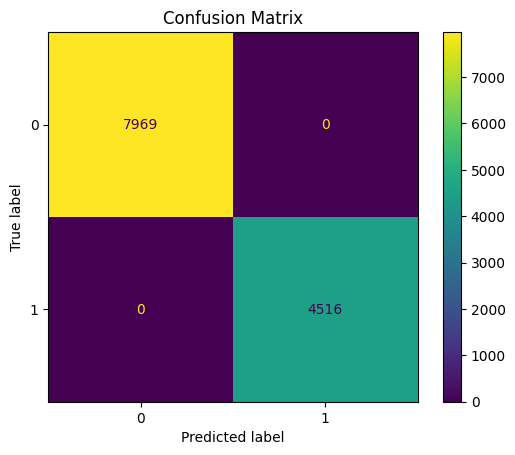

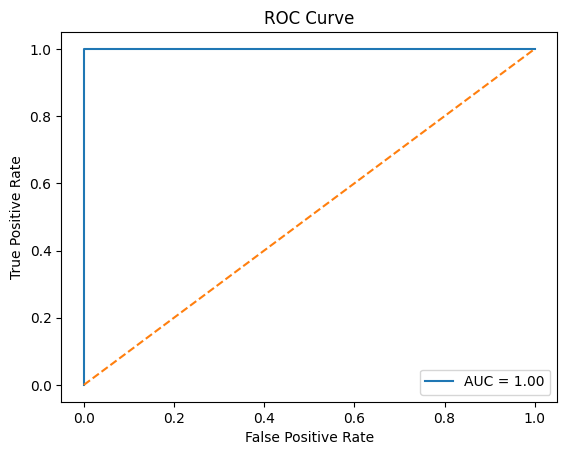

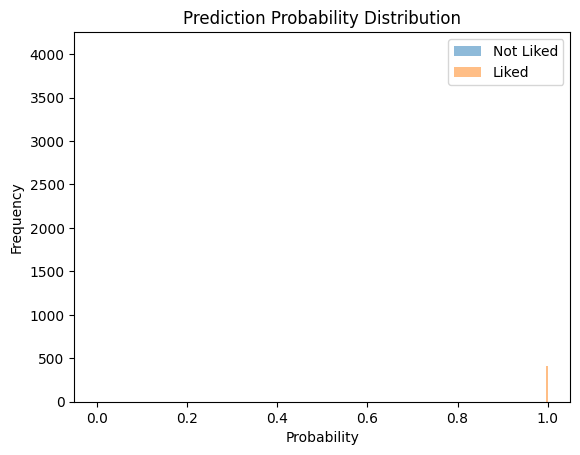

Accuracy: 1.0


In [5]:
# -----------------------------------
# 1. Import Libraries
# -----------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_curve, auc
)
from sklearn.linear_model import LogisticRegression

# -----------------------------------
# 2. Load Dataset
# -----------------------------------
df = pd.read_csv("movies.csv")

# -----------------------------------
# 3. Feature Engineering
# -----------------------------------
# Convert genres into numerical features
df['Action'] = df['genres'].apply(lambda x: 1 if 'Action' in x else 0)
df['Comedy'] = df['genres'].apply(lambda x: 1 if 'Comedy' in x else 0)
df['Drama'] = df['genres'].apply(lambda x: 1 if 'Drama' in x else 0)
df['Romance'] = df['genres'].apply(lambda x: 1 if 'Romance' in x else 0)

# -----------------------------------
# 4. Create Target (LIKE PAPER STYLE)
# -----------------------------------
# Assume user likes Action + Comedy movies
df['liked'] = ((df['Action'] == 1) | (df['Comedy'] == 1)).astype(int)

# Features & Target
X = df[['Action', 'Comedy', 'Drama', 'Romance']]
y = df['liked']

# -----------------------------------
# 5. Train-Test Split
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------------
# 6. Model
# -----------------------------------
model = LogisticRegression()
model.fit(X_train, y_train)

# -----------------------------------
# 7. Predictions
# -----------------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# -----------------------------------
# 8. Classification Report
# -----------------------------------
print(classification_report(y_test, y_pred))

# -----------------------------------
# 9. Confusion Matrix
# -----------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# -----------------------------------
# 10. ROC Curve
# -----------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -----------------------------------
# 11. Probability Distribution
# -----------------------------------
plt.hist(y_prob[y_test == 0], bins=10, alpha=0.5, label="Not Liked")
plt.hist(y_prob[y_test == 1], bins=10, alpha=0.5, label="Liked")

plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.title("Prediction Probability Distribution")
plt.legend()
plt.show()

# -----------------------------------
# 12. Accuracy
# -----------------------------------
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)